In [1]:
print("h")

h


In [2]:
from sklearn.datasets import make_regression
import numpy as np

# to make a small dataset
X,y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

In [36]:
X

array([[ 2.10639659e+00],
       [-1.29651000e+00],
       [ 7.78021090e-01],
       [-1.29367548e+00],
       [-8.35147491e-01],
       [-1.30764895e-03],
       [ 2.12015431e-01],
       [ 1.12253683e+00],
       [ 9.94015606e-01],
       [ 6.36598509e-01],
       [-2.09427426e+00],
       [-8.04874931e-01],
       [-7.77566500e-01],
       [ 9.25605523e-01],
       [ 3.87417373e-01],
       [-1.44061252e+00],
       [-3.08013895e-01],
       [-1.04503536e-01],
       [-7.03533474e-01],
       [-1.22902015e+00],
       [ 4.25555661e-01],
       [ 6.91510623e-01],
       [ 7.94835892e-01],
       [ 1.96309797e-01],
       [ 5.62270292e-01],
       [-1.84584416e+00],
       [-2.71151733e-01],
       [-1.62821999e-01],
       [-8.61526629e-01],
       [-1.22920500e+00],
       [-8.73325780e-01],
       [-3.40715799e-01],
       [ 1.13246551e+00],
       [ 1.21226492e+00],
       [ 8.65569817e-01],
       [ 2.81792715e-01],
       [ 9.42345062e-01],
       [ 5.44364993e-01],
       [-8.6

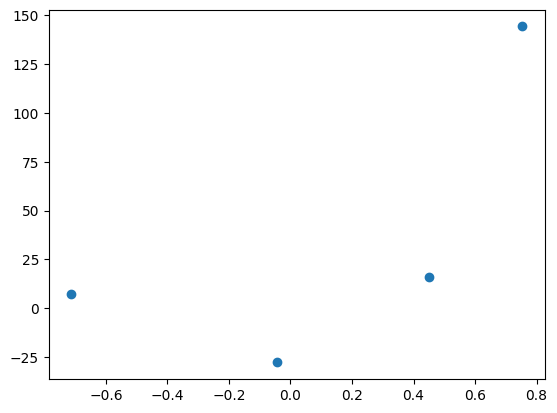

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [7]:
from sklearn.linear_model import LinearRegression

reg=LinearRegression()
reg.fit(X,y)
print(f"reg.coef_ = {reg.coef_}")
print(f"reg_intercept_ = {reg.intercept_}")
print(f"red_predict_ = {reg.predict(X)}")


reg.coef_ = [78.35063668]
reg_intercept_ = 26.15963284313262
red_predict_ = [-29.65662909  61.55941724  22.67278832  85.21770852]


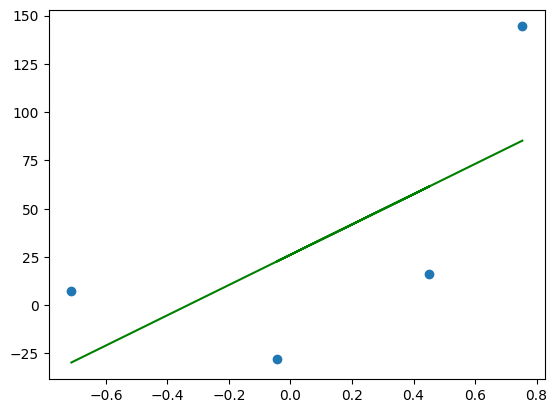

In [5]:
# to draw a best fit regression line

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='green')

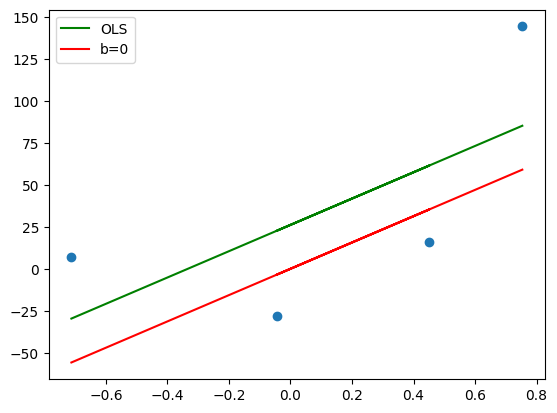

In [12]:
 # keeping m constant and b=0 a wrong line apply gradient_descent

y_pred=((78.35*X)+0).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="green",label='OLS')
plt.plot(X,y_pred,color='red',label='b=0')
plt.legend()
plt.show()

In [14]:
m=78.35
b=0
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
lr=0.1
# alpha*slpoe=stepsize
step_size=lr*loss_slope
print(step_size)
#new b
b=b-step_size
print(b)


-20.927763408209216
20.927763408209216


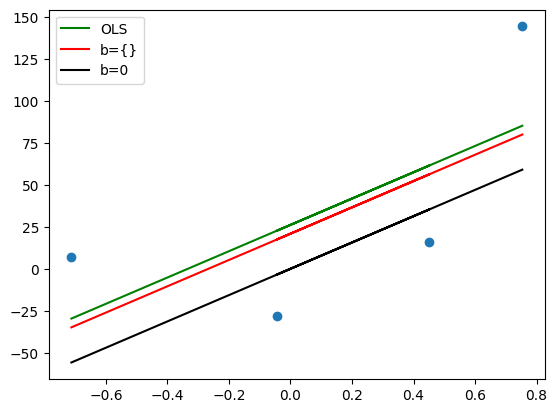

In [16]:
y_pred1=((78.35*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="green",label='OLS')
plt.plot(X,y_pred1,color='red',label='b={}')
plt.plot(X,y_pred,color='black',label='b=0')
plt.legend()
plt.show()


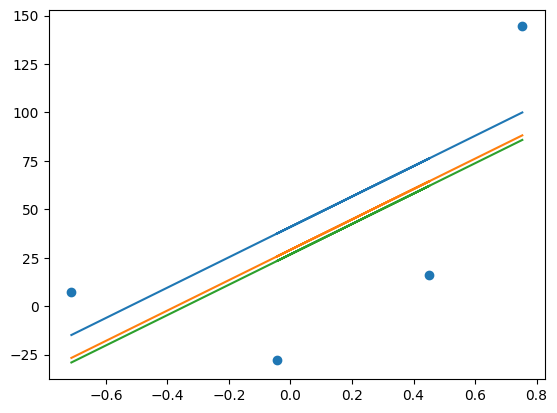

In [31]:
m = 78.35
b = 100
lr=0.1
for epoch in range(3):    
    loss_slope = -2 * np.sum(y - (m * X.ravel() + b))
    
    step_size = lr * loss_slope
    b = b - step_size
    y_pred = m*X+b
    plt.plot(X,y_pred)

# y_pred1 = m * X.ravel() + b

plt.scatter(X, y)
# plt.plot(X, reg.predict(X), color="green", label='OLS')
# plt.plot(X, y_pred1, color='red', label='b after GD')
# plt.plot(X, m * X + 0, color='black', label='b=0')
# plt.legend()
# plt.show()

##GD

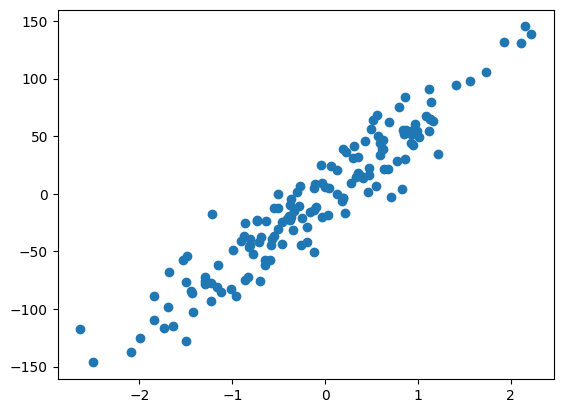

In [33]:
from sklearn.datasets import make_regression
X,y=make_regression(n_samples=150,n_features=1,n_informative=1,n_targets=1,noise=20)
plt.scatter(X,y)

In [34]:
linr=LinearRegression()
linr.fit(X,y)
print(f"m={linr.coef_}")
print(f"b={linr.intercept_}")

m=[58.78271741]
b=0.2692915512872114


In [ ]:
class GDRegression:
    def __init__(self,learning_rate=0.01,epochs=1000):
        self.m=0
        self.b=-120
        self.lr=learning_rate
        self.epochs=epochs

        self.m_history=[]
        self.b_history=[]

    def fit(self,X,y):
        #to calculate b  amd using Gradient descent

        X=X.ravel()
        n=len(X)

        for epoch in range(self.epochs):
            y_pred = self.m * X + self.b

            #Gradients
            dm = (-2/n) *  np.sum(X*(y-y_pred))
            db= (-2/n) *  np.sum(y-y_pred)
            
            # step size = lr*dm
            # loss = m=m-step size
            self.m -= self.lr * dm
            self.b -= self.lr * db
            self.m_history.append(self.m)
            self.b_history.append(self.b)
            # print loss 
            if epoch % 100 ==0:
                loss = np.mean((y-y_pred)**2)
                print(f"epoch = {epoch} loss : {loss} m= {self.m} b= {self.b}")


    def predict(self,X):
        return self.m*X + self.b



In [53]:
gd = GDRegression()
gd.fit(X,y)


epoch = 0 loss : 16591.245236244573 m= 0.8640232328611509 b= -117.7190022242474
epoch = 100 loss : 762.861087099241 m= 46.534382393590164 b= -17.508593060193277
epoch = 200 loss : 347.2027765564564 m= 56.40997737402774 b= -2.5161448415916743
epoch = 300 loss : 335.42126936670905 m= 58.34303389356736 b= -0.18088350265609543
epoch = 400 loss : 335.0749026883123 m= 58.703241637690375 b= 0.19483146777127366
epoch = 500 loss : 335.0645545551784 m= 58.76856116976885 b= 0.25677100669148584
epoch = 600 loss : 335.0642432740356 m= 58.78021840108095 b= 0.26716218901382977
epoch = 700 loss : 335.06423388370763 m= 58.78227871121543 b= 0.26892663899042774
epoch = 800 loss : 335.0642336000976 m= 58.78264066672014 b= 0.26922869918241277
epoch = 900 loss : 335.06423359152785 m= 58.7827040150471 b= 0.26928068985835096


In [ ]:
gd.m_history

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

model = GDRegression(0.001,50)
model.fit(X, y)

fig, ax = plt.subplots()
ax.scatter(X, y)

line, = ax.plot([], [], color='red')

def update(frame):
    m = model.m_history[frame]
    b = model.b_history[frame]
    
    y_pred = m * X.ravel() + b
    line.set_data(X, y_pred)
    
    return line,

ani = FuncAnimation(fig, update, frames=len(model.m_history), interval=200)

plt.show()
plt.close()

In [61]:
class MiniBatchGradient:
    def __init__ (self,lr=0.01,epochs=1000,batch_size=4):
        self.lr=lr
        self.batches=batch_size
        self.epochs=epochs

        self.m=0
        self.b=0

        self.m_history=[]
        self.b_history=[]
        self.loss_history=[]

    def fit(self,X,y):
        X=X.ravel()
        y=y.ravel()
        n=len(X)

        for epoch in range(self.epochs):
            #shuffle data every epoch
            indices=np.random.permutation(n)
            X_shuffled=X[indices]
            y_shuffled=y[indices]
            for i in range(0,n,self.batches):
                X_batch=X_shuffled[i:i+self.batches]
                y_batch=y_shuffled[i:i+self.batches]

                y_pred=self.m*X_batch + self.b

                #gradient

                dm = (-2/len(X_batch)) * np.sum(X_batch*(y_batch-y_pred))
                db = (-2/len(X_batch)) * np.sum(y_batch - y_pred)

                self.m -= self.lr * dm
                self.b -= self.lr * db

            y_full_pred = self.m * X + self.b
            loss = np.mean((y-y_full_pred)**2)

            self.loss_history.append(loss)
            self.m_history.append(self.m)
            self.b_history.append(self.b)

            if epoch % 10 == 0:
                print(f"Epoch = {epoch} loss : {loss:.4f} m = {m} b = {b}")

    def predict(self,X):
        return self.m * X + self.b
    

miniBatch=MiniBatchGradient()
miniBatch.fit(X,y)




        

Epoch = 0 loss : 1096.1447 m = 78.35 b = 26.75042662617943
Epoch = 10 loss : 335.1273 m = 78.35 b = 26.75042662617943
Epoch = 20 loss : 335.0997 m = 78.35 b = 26.75042662617943
Epoch = 30 loss : 335.2687 m = 78.35 b = 26.75042662617943
Epoch = 40 loss : 335.4512 m = 78.35 b = 26.75042662617943
Epoch = 50 loss : 335.0872 m = 78.35 b = 26.75042662617943
Epoch = 60 loss : 335.1855 m = 78.35 b = 26.75042662617943
Epoch = 70 loss : 335.0741 m = 78.35 b = 26.75042662617943
Epoch = 80 loss : 335.2375 m = 78.35 b = 26.75042662617943
Epoch = 90 loss : 335.1160 m = 78.35 b = 26.75042662617943
Epoch = 100 loss : 335.1056 m = 78.35 b = 26.75042662617943
Epoch = 110 loss : 335.0871 m = 78.35 b = 26.75042662617943
Epoch = 120 loss : 335.0933 m = 78.35 b = 26.75042662617943
Epoch = 130 loss : 335.0892 m = 78.35 b = 26.75042662617943
Epoch = 140 loss : 335.1518 m = 78.35 b = 26.75042662617943
Epoch = 150 loss : 335.1095 m = 78.35 b = 26.75042662617943
Epoch = 160 loss : 335.0927 m = 78.35 b = 26.75042